In [1]:
pip install librosa

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Affan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import os
import librosa
import soundfile as sf
import numpy as np
import warnings

warnings.filterwarnings('ignore')

CLEAN_AUDIO_DIR = r"E:\SSP-Project-V1\wav"
NOISE_DIR = "DEMAND_Noises"
OUTPUT_BASE_DIR = "Noisy_EmoDB"

SNR_LEVELS = [15, 10, 5, 0, -5, -10]

NOISE_TYPES = {
    'Cafe': 'cafe_noise.wav',
    'Street': 'street_noise.wav'
}

def calculate_rms(signal):
    return np.sqrt(np.mean(signal**2))

def inject_physical_noise(clean_signal, noise_signal, snr):
    clean_rms = calculate_rms(clean_signal)
    noise_rms = calculate_rms(noise_signal)
    
    if noise_rms == 0:
        return clean_signal
        
    desired_noise_rms = clean_rms / (10 ** (snr / 20))
    adjusted_noise = noise_signal * (desired_noise_rms / noise_rms)
    noisy_signal = clean_signal + adjusted_noise
    
    max_val = np.max(np.abs(noisy_signal))
    if max_val > 1.0:
        noisy_signal = noisy_signal / max_val
        
    return noisy_signal

def process_dataset():
    print("[INFO] Starting noise injection process...")
    
    os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)
    clean_files = [f for f in os.listdir(CLEAN_AUDIO_DIR) if f.endswith('.wav')]
    print(f"[INFO] Found {len(clean_files)} clean audio files.")
    
    loaded_noises = {}
    for noise_name, noise_file in NOISE_TYPES.items():
        noise_path = os.path.join(NOISE_DIR, noise_file)
        if os.path.exists(noise_path):
            n_sig, _ = librosa.load(noise_path, sr=16000)
            loaded_noises[noise_name] = n_sig
        else:
            print(f"[WARNING] Physical noise file not found: {noise_path}")
            
    for snr in SNR_LEVELS:
        for noise_name, noise_signal in loaded_noises.items():
            folder_name = f"{noise_name}_{snr}dB"
            output_dir = os.path.join(OUTPUT_BASE_DIR, folder_name)
            os.makedirs(output_dir, exist_ok=True)
            print(f"[PROCESS] Generating {folder_name}")
            
            for f_name in clean_files:
                clean_path = os.path.join(CLEAN_AUDIO_DIR, f_name)
                y_clean, sr = librosa.load(clean_path, sr=16000)
                
                if len(noise_signal) < len(y_clean):
                    n_sig_padded = np.tile(noise_signal, int(np.ceil(len(y_clean)/len(noise_signal))))
                    n_sig_padded = n_sig_padded[:len(y_clean)]
                else:
                    start_idx = np.random.randint(0, len(noise_signal) - len(y_clean))
                    n_sig_padded = noise_signal[start_idx : start_idx + len(y_clean)]
                    
                y_noisy = inject_physical_noise(y_clean, n_sig_padded, snr)
                sf.write(os.path.join(output_dir, f_name), y_noisy, sr)
                
        white_folder = f"White_{snr}dB"
        white_dir = os.path.join(OUTPUT_BASE_DIR, white_folder)
        os.makedirs(white_dir, exist_ok=True)
        print(f"[PROCESS] Generating {white_folder}")
        
        for f_name in clean_files:
            clean_path = os.path.join(CLEAN_AUDIO_DIR, f_name)
            y_clean, sr = librosa.load(clean_path, sr=16000)
            
            signal_power = np.mean(y_clean ** 2)
            white_noise = np.random.normal(0, 1, len(y_clean))
            noise_power = np.mean(white_noise ** 2)
            
            snr_linear = 10 ** (snr / 10)
            target_noise_power = signal_power / (snr_linear + 1e-10) 
            scaling_factor = np.sqrt(target_noise_power / (noise_power + 1e-10))
            
            scaled_noise = white_noise * scaling_factor
            y_noisy = y_clean + scaled_noise
            
            if np.max(np.abs(y_noisy)) > 0:
                y_noisy = y_noisy / np.max(np.abs(y_noisy))
                
            sf.write(os.path.join(white_dir, f_name), y_noisy, sr)
            
    print("[SUCCESS] All noisy datasets generated.")

if __name__ == "__main__":
    process_dataset()

[INFO] Starting noise injection process...
[INFO] Found 535 clean audio files.
[PROCESS] Generating Cafe_15dB
[PROCESS] Generating Street_15dB
[PROCESS] Generating White_15dB
[PROCESS] Generating Cafe_10dB
[PROCESS] Generating Street_10dB
[PROCESS] Generating White_10dB
[PROCESS] Generating Cafe_5dB
[PROCESS] Generating Street_5dB
[PROCESS] Generating White_5dB
[PROCESS] Generating Cafe_0dB
[PROCESS] Generating Street_0dB
[PROCESS] Generating White_0dB
[PROCESS] Generating Cafe_-5dB
[PROCESS] Generating Street_-5dB
[PROCESS] Generating White_-5dB
[PROCESS] Generating Cafe_-10dB
[PROCESS] Generating Street_-10dB
[PROCESS] Generating White_-10dB
[SUCCESS] All noisy datasets generated.


Generating Emotion-Noise Waveform Grid (7 Emotions x 4 Environments)...


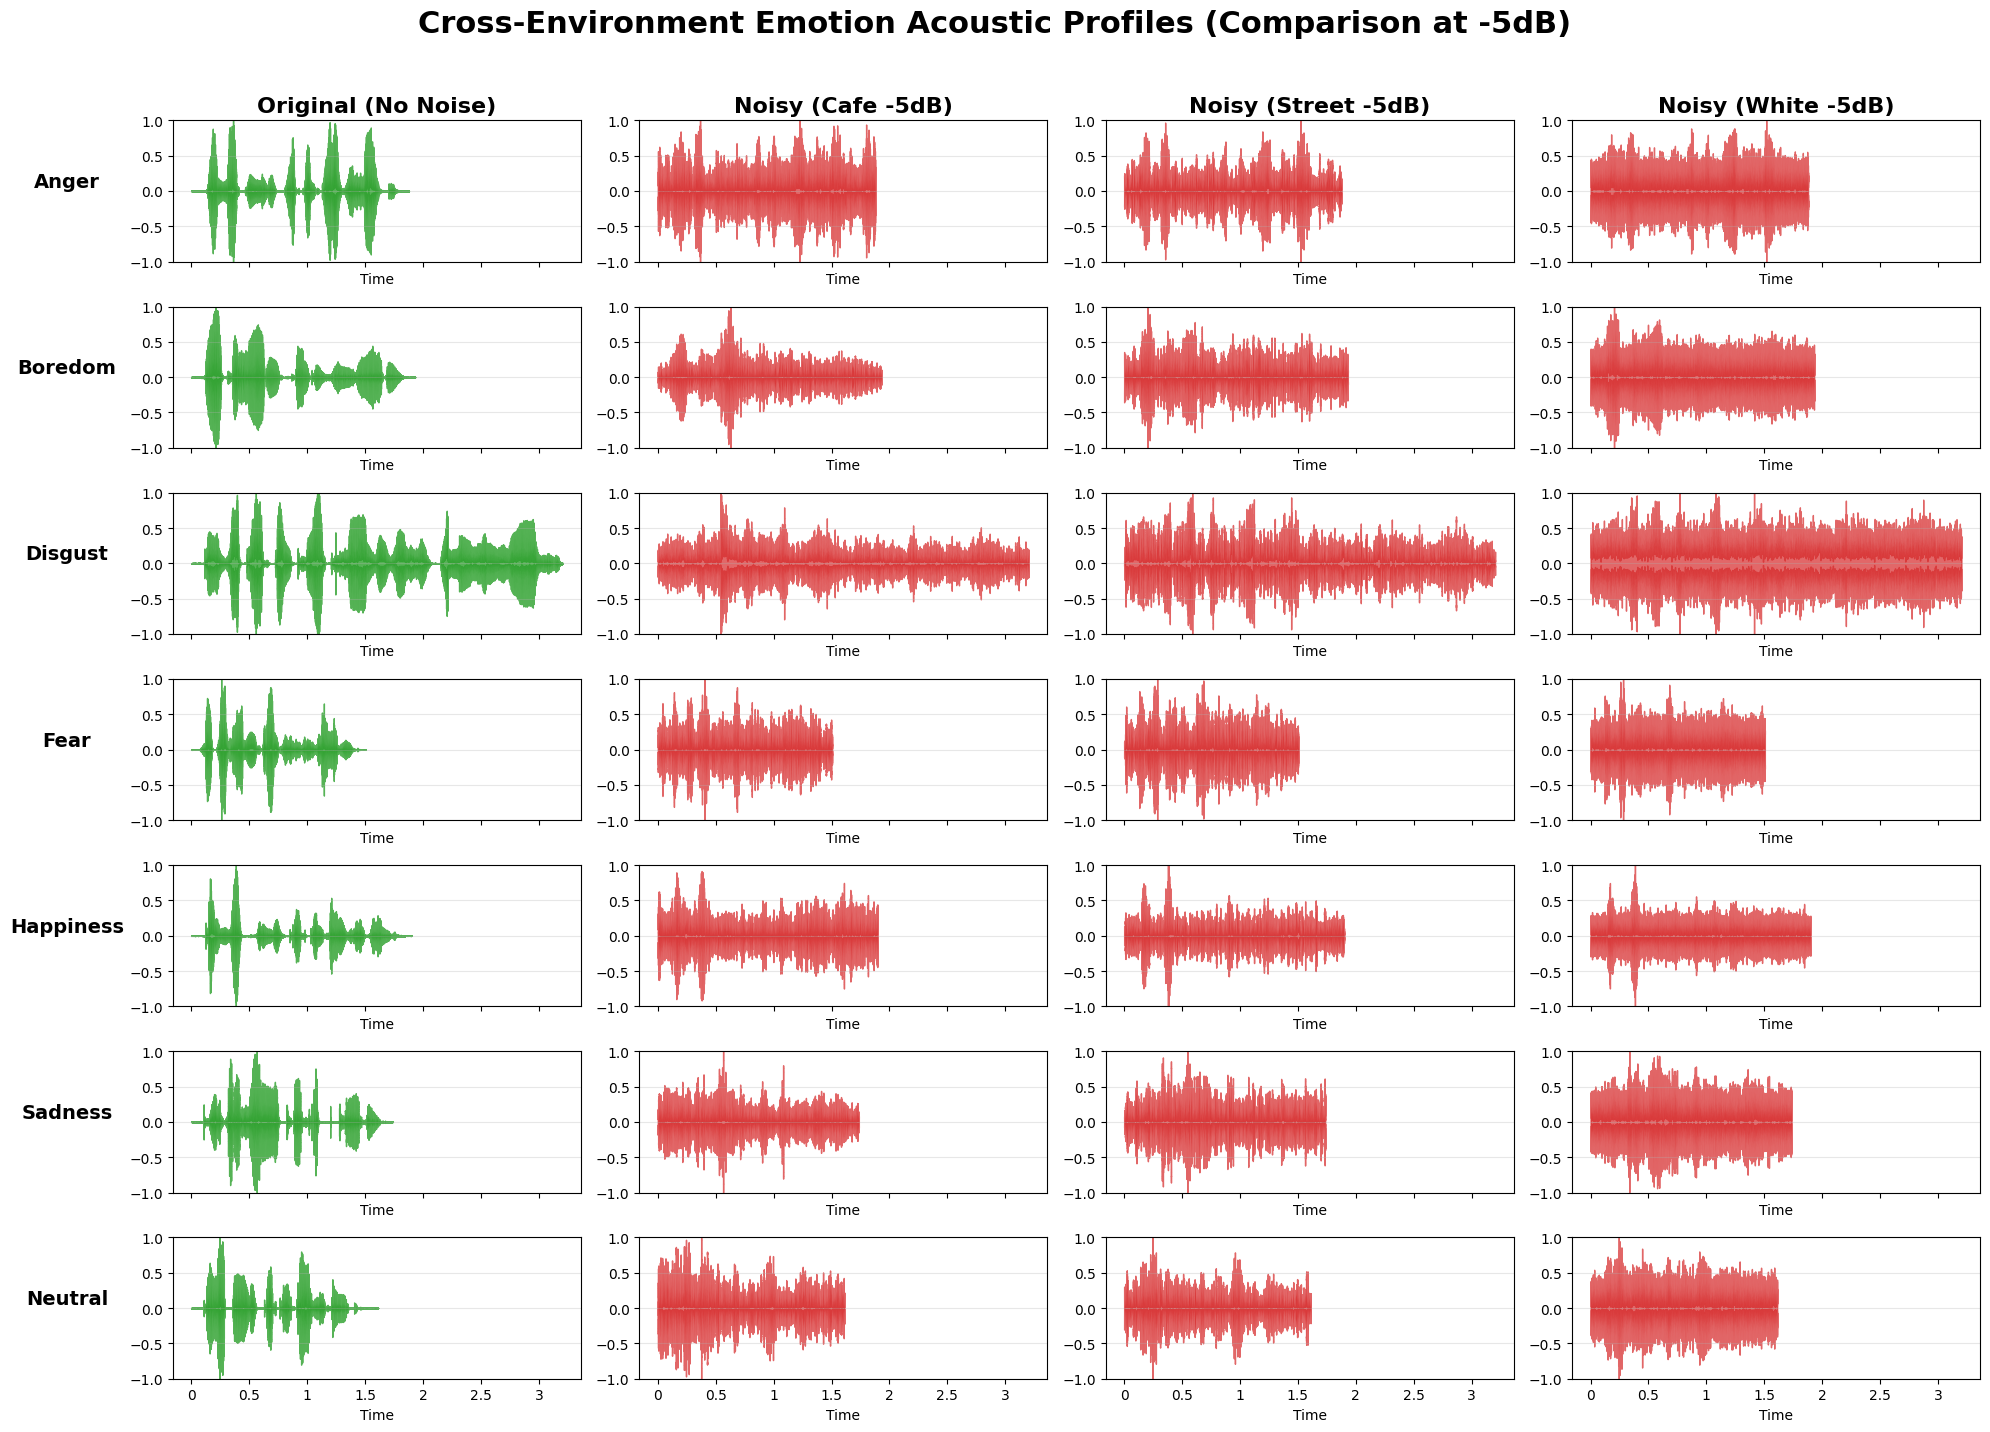

Emotion-Noise grid saved to: images\Visualization_2_Emotion_Grid.png


In [8]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

print("Generating Emotion-Noise Waveform Grid (7 Emotions x 4 Environments)...")

original_db_dir = r"E:\SSP-Project-V1\wav" 
noisy_base_dir = "Noisy_EmoDB"
img_dir = "images"
os.makedirs(img_dir, exist_ok=True)

emotion_full_map = {"W": "Anger", "L": "Boredom", "E": "Disgust", "A": "Fear", "F": "Happiness", "T": "Sadness", "N": "Neutral"}
emotion_chars = ["W", "L", "E", "A", "F", "T", "N"]
comparison_snr = "-5dB" 

noise_envs = ["Cafe", "Street", "White"] 

fig, axes = plt.subplots(nrows=len(emotion_chars), ncols=4, figsize=(20, 14), sharex=True)

all_clean_files = [f for f in os.listdir(original_db_dir) if f.endswith('.wav')]

for row_idx, emotion_char in enumerate(emotion_chars):
    clean_files_for_emo = [f for f in all_clean_files if len(f) > 5 and f[5] == emotion_char]
    if not clean_files_for_emo: continue 
    target_file = clean_files_for_emo[0] 
    
    # 1. Original (No Noise)
    ax_clean = axes[row_idx, 0]
    y_c, sr_c = librosa.load(os.path.join(original_db_dir, target_file), sr=16000)
    librosa.display.waveshow(y_c, sr=sr_c, ax=ax_clean, color='#2ca02c', alpha=0.8)
    ax_clean.set_ylabel(emotion_full_map[emotion_char], fontsize=14, fontweight='bold', rotation=0, labelpad=45)
    if row_idx == 0: ax_clean.set_title("Original (No Noise)", fontsize=16, fontweight='bold')
    ax_clean.set_ylim(-1, 1)
    ax_clean.grid(True, axis='y', alpha=0.3)

    # 2. Noisy Environments
    for col_idx, env_name in enumerate(noise_envs):
        ax_noisy = axes[row_idx, col_idx + 1] 
        full_env_path = os.path.join(noisy_base_dir, f"{env_name}_{comparison_snr}", target_file)
        
        try:
            y_n, _ = librosa.load(full_env_path, sr=16000)
            librosa.display.waveshow(y_n, sr=16000, ax=ax_noisy, color='#d62728', alpha=0.7)
            if row_idx == 0: ax_noisy.set_title(f"Noisy ({env_name} {comparison_snr})", fontsize=16, fontweight='bold')
            ax_noisy.set_ylim(-1, 1)
            ax_noisy.grid(True, axis='y', alpha=0.3)
        except FileNotFoundError:
            ax_noisy.text(0.5, 0.5, 'File N/A', horizontalalignment='center', verticalalignment='center')

plt.suptitle(f"Cross-Environment Emotion Acoustic Profiles (Comparison at {comparison_snr})", fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()

save_path2 = os.path.join(img_dir, 'Visualization_2_Emotion_Grid.png')
plt.savefig(save_path2, dpi=300, bbox_inches='tight')
plt.show()
print(f"Emotion-Noise grid saved to: {save_path2}")